# Prétraiter et affiner les modèles basés sur des transformateurs

 #### 1. Bert vs XLM-RoBerta

 ##### **Différences entre BERT et XLM-RoBERTa**

BERT est un modèle bidirectionnel qui analyse le contexte d’un mot en regardant à gauche et à droite.

XLM-RoBERTa est une amélioration de RoBERTa, lui-même basé sur BERT, avec un pré-entraînement plus long et des stratégies d’apprentissage plus avancées.

* Gestion des séquences longues

     * BERT et XLM-RoBERTa ont une limite de 512 tokens, ce qui peut être un obstacle pour les longs textes.

     * Ils nécessitent des stratégies comme le truncation ou le windowing pour traiter les séquences longues.

* Support multilingue et pré-entraînement

     * BERT a été initialement entraîné sur des textes en anglais, bien qu’il existe une version multilingue (bert-multilingual-cased).

     * XLM-RoBERTa est entièrement multilingue, entraîné sur 100 langues sans nécessiter de modèles spécifiques.

     Son pré-entraînement repose sur une plus grande quantité de données, ce qui le rend plus performant pour le NLP multilingue.



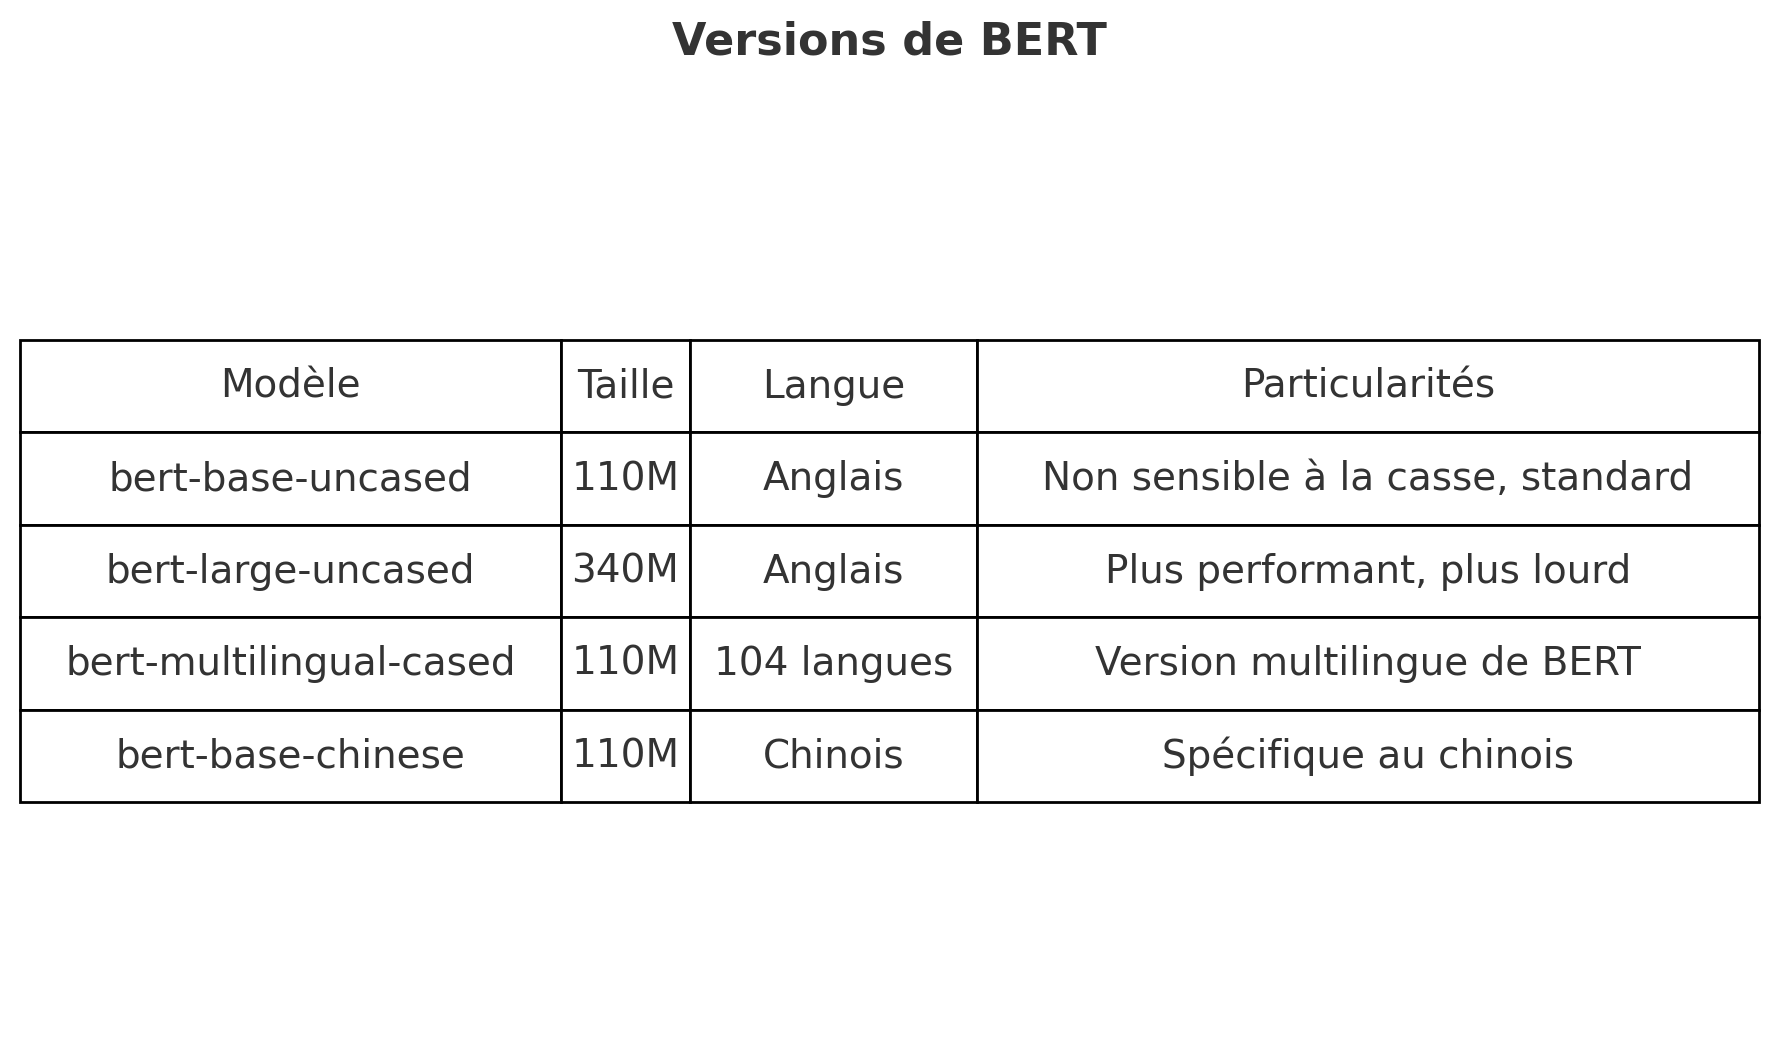

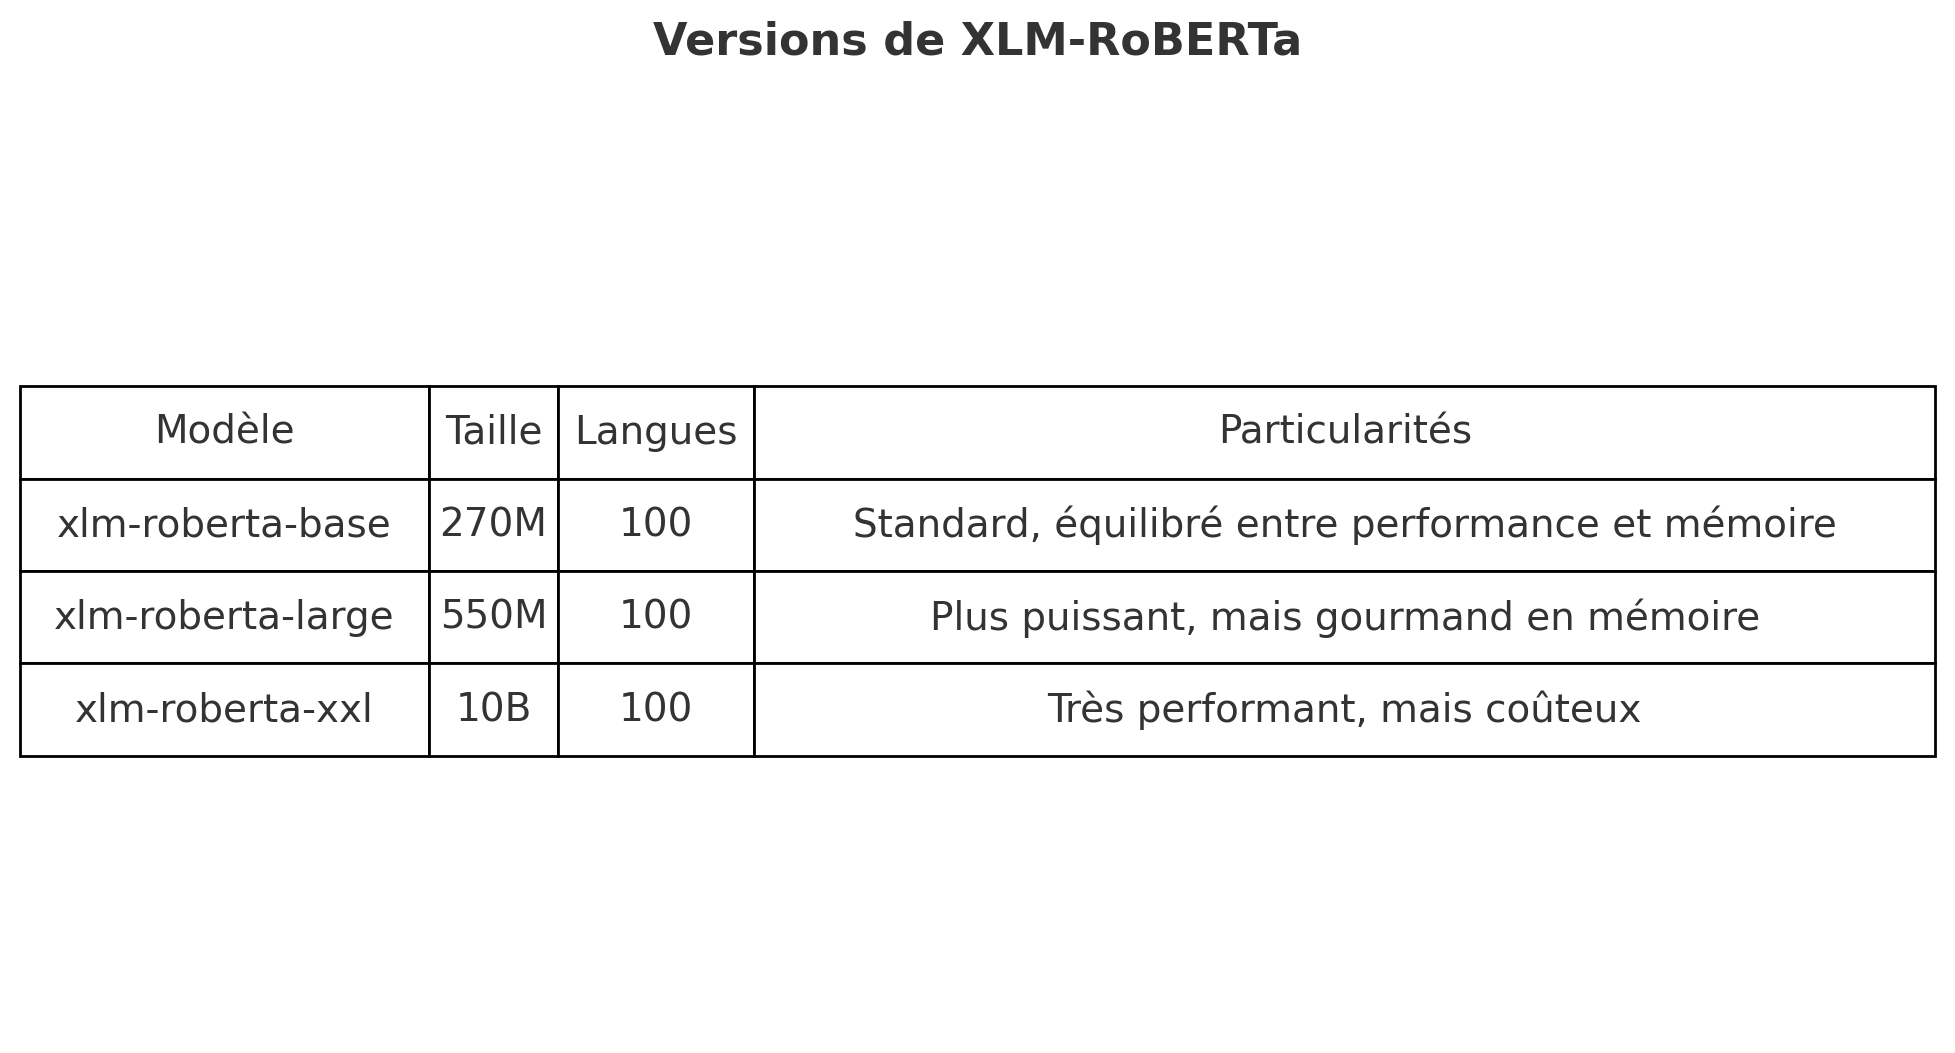

In [5]:
from IPython.display import display, Image

# Chemins des fichiers (à ajuster selon l'emplacement dans ton notebook Kaggle)
bert_image_path = "bert_versions.png"
xlm_roberta_image_path = "xlm_roberta_versions.png"

# Affichage des images
display(Image(bert_image_path))
display(Image(xlm_roberta_image_path))



In [10]:
from google.colab import files
from IPython.display import clear_output
import shutil
import os

# Téléchargement du fichier
uploaded = files.upload()

# Effacer l'affichage pour ne pas afficher le contenu du fichier
clear_output()

# Récupération du nom du fichier
file_name = list(uploaded.keys())[0]

# Vérifier si un fichier du même nom existe déjà et le remplacer
if os.path.exists("train.csv"):
    os.remove("train.csv")  # Supprimer l'ancien fichier pour éviter les doublons

# Renommer et déplacer le fichier téléchargé
shutil.move(file_name, "train.csv")

print("Fichier uploadé")


Fichier uploadé


In [11]:
import pandas as pd
from transformers import BertTokenizer, XLMRobertaTokenizer


In [12]:
df = pd.read_csv('train.csv')
df.shape

(12120, 6)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          12120 non-null  object
 1   premise     12120 non-null  object
 2   hypothesis  12120 non-null  object
 3   lang_abv    12120 non-null  object
 4   language    12120 non-null  object
 5   label       12120 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 568.3+ KB


In [14]:
df.sample(10)

,id,premise,hypothesis,lang_abv,language,label
3705,1b9c14a66b,"The Honorable Bill Archer, Chairman The Honora...",Bill Archer is a member of the House of Repres...,en,English,0
8977,a178cd59fb,The arched gateway leads to a large swimming p...,There is a bathing complex past the gateway.,en,English,0
3115,aa7ebd7a45,The large scale production of entertainment fi...,The production of entertainment films is elabo...,en,English,0
2415,d6002c9558,"The Standard , published a few days before Den...",The Standard covers similar territory about mi...,en,English,1
346,a5da185d23,but uh these guys were actually on the road uh...,These men filed their midterm exams from home.,en,English,2
9319,7e1a365866,"Cependant, le SAB, soutenu par une littérature...",Le CCS a complètement ignoré le sujet.,fr,French,2
76,de5351757f,"ตรงกันข้าม, ใน Cite de la Musique คือ Musee de...",ซีนีนคือลานคอนเสริตขนาดใหญ่,th,Thai,0
11407,554748adc4,"Almost directly overhead, there was a rent pla...",The rent place was in a poor part of town.,en,English,1
5646,3d710521eb,"Just like we have hairpins and powder-puffs."" ...",Tommy handed Tuppence a red notebook.,en,English,2
2879,ad4794f489,听听这位绅士！他嘲笑到。,他取笑了那个男人。,zh,Chinese,0


In [15]:
df["premise"].values

array(['and these comments were considered in formulating the interim rules.',
       'These are issues that we wrestle with in practice groups of law firms, she said. ',
       "Des petites choses comme celles-là font une différence énorme dans ce que j'essaye de faire.",
       ...,
       "The important thing is to realize that it's way past time to move it.",
       'At the west end is a detailed model of the whole temple complex.',
       'For himself he chose Atat??rk, or Father of the Turks.'],
      dtype=object)

In [16]:
df["hypothesis"].values

array(['The rules developed in the interim were put together with these comments in mind.',
       'Practice groups are not permitted to work on these issues.',
       "J'essayais d'accomplir quelque chose.", ...,
       'It cannot be moved, now or ever.',
       'The model temple complex is at the east end.',
       'Ataturk was the father of the Turkish nation.'], dtype=object)

In [17]:
df.isnull().sum()

,0
id,0
premise,0
hypothesis,0
lang_abv,0
language,0
label,0


#### 2. Tokenisation du texte
Objectif : comprendre comment tokeniser du texte à l’aide de tokeniseurs pré-entraînés.

In [18]:
# Charger les tokenizers pour BERT et XLM-RoBERTa
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
xlm_roberta_tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

# Vérifier les tokens spéciaux et la taille du vocabulaire
print(" - Tokens spéciaux (BERT) :", bert_tokenizer.special_tokens_map)
print(" - Taille du vocabulaire (BERT) :", bert_tokenizer.vocab_size, "\n")

print(" - Tokens spéciaux (XLM-RoBERTa) :", xlm_roberta_tokenizer.special_tokens_map)
print(" - Taille du vocabulaire (XLM-RoBERTa) :", xlm_roberta_tokenizer.vocab_size)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

 - Tokens spéciaux (BERT) : {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}
 - Taille du vocabulaire (BERT) : 119547 

 - Tokens spéciaux (XLM-RoBERTa) : {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}
 - Taille du vocabulaire (XLM-RoBERTa) : 250002


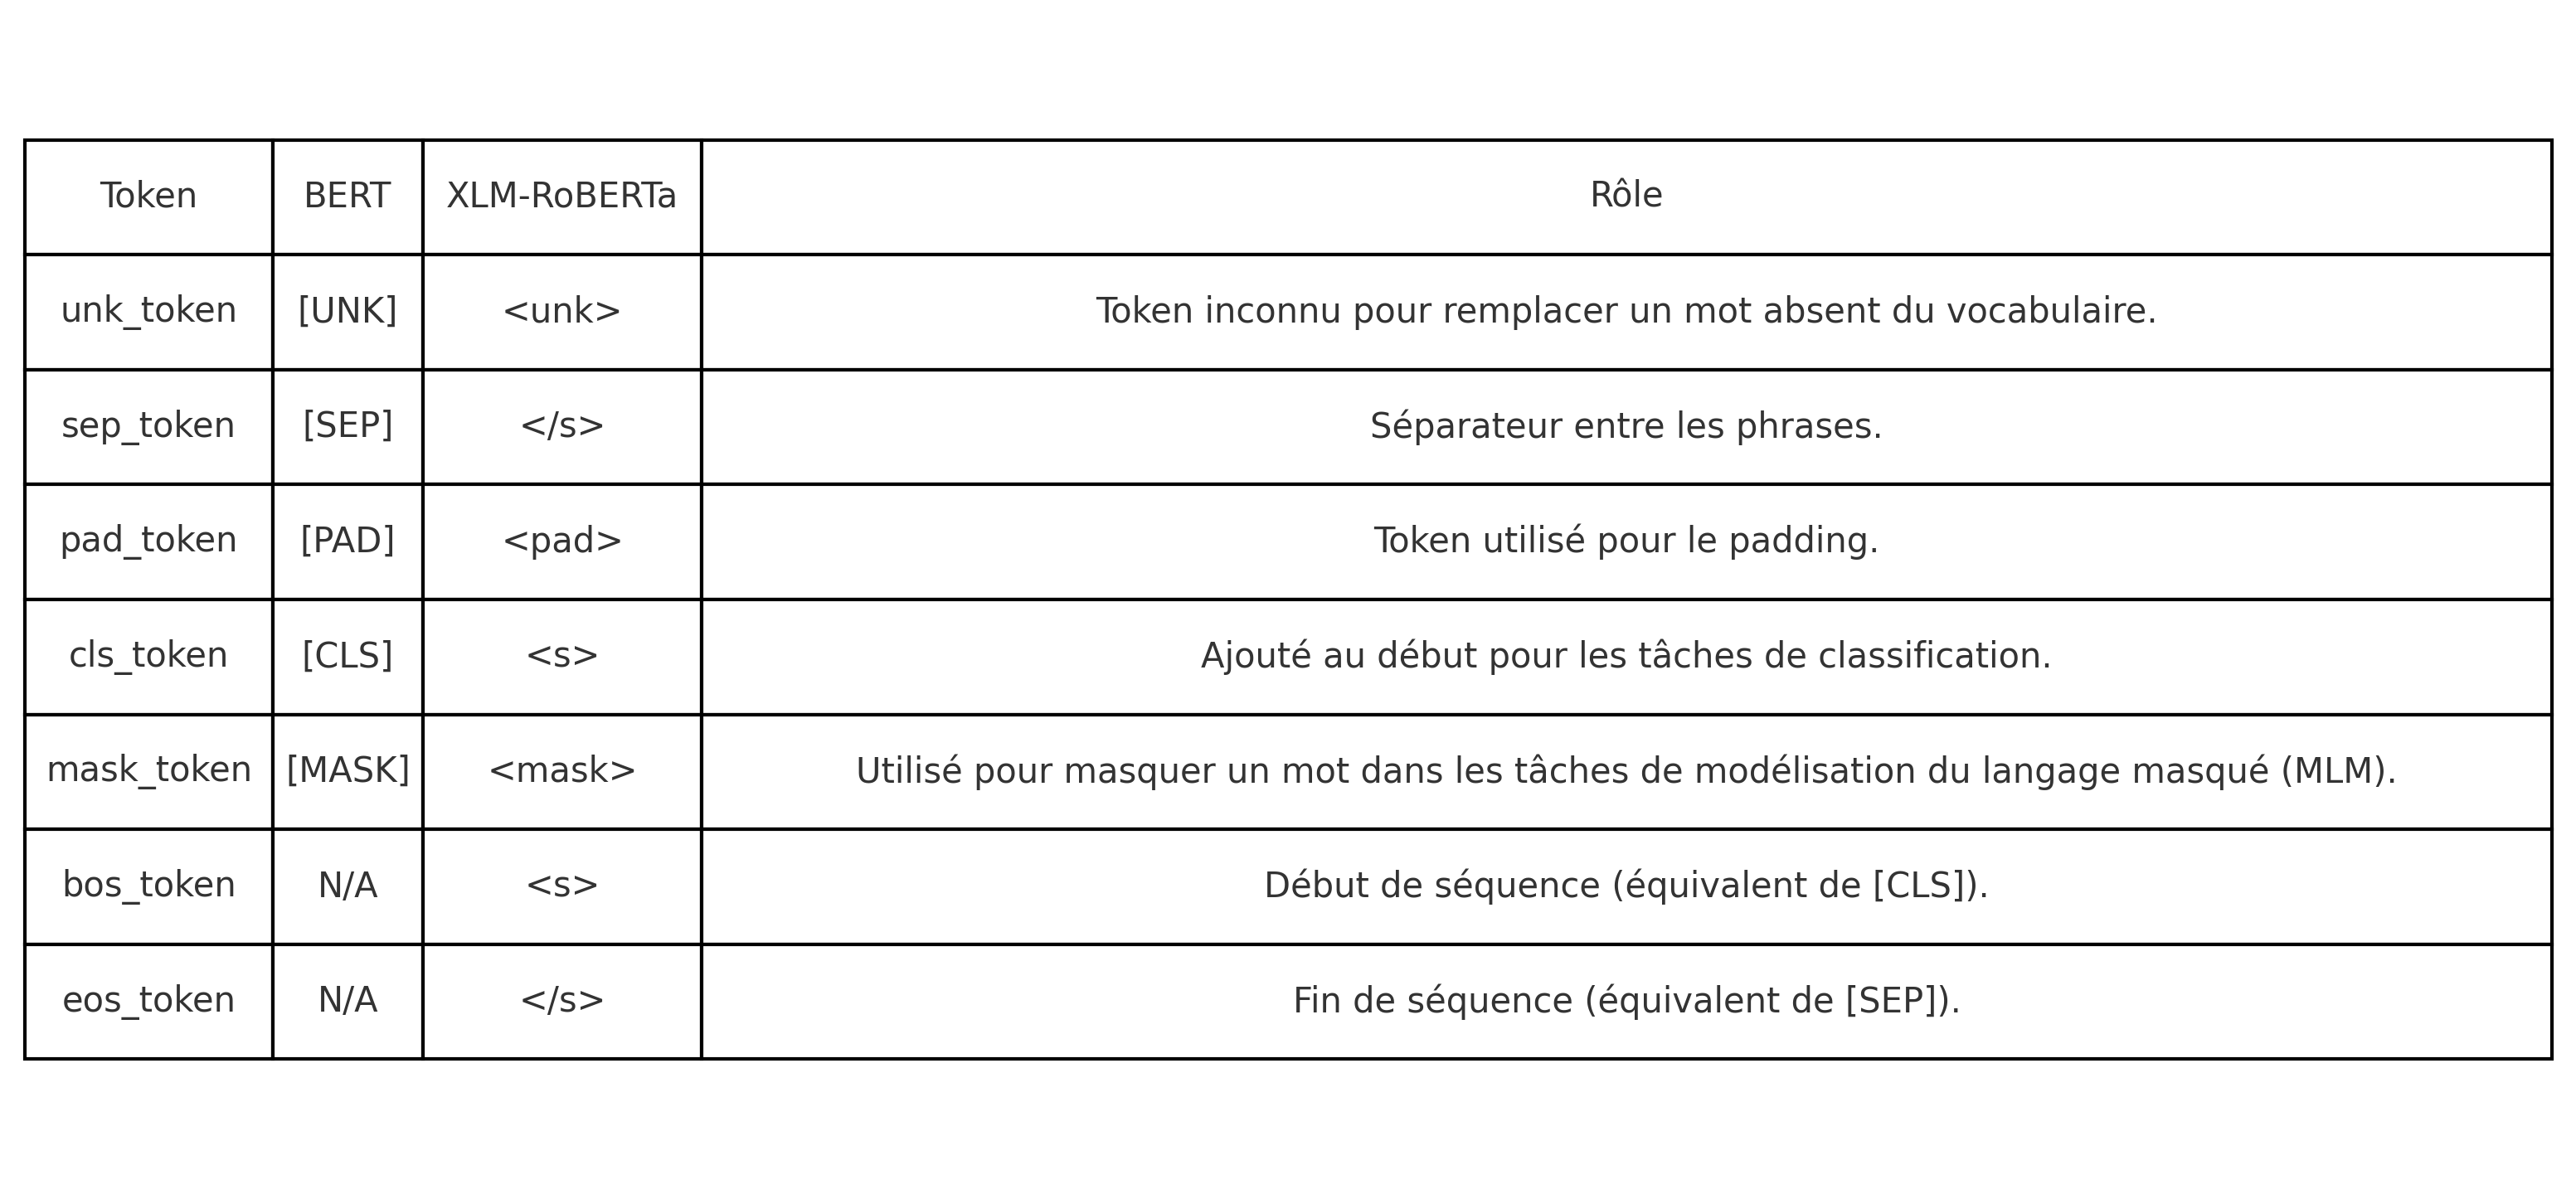

In [20]:
special_tokens_comparaison = "special_tokens_comparison.png"
display(Image(special_tokens_comparaison))

Préparation des inputs avant tokenization

In [37]:
def format_inputs(df, tokenizer, model_name):
    formatted_data = []

    for premise, hypothesis in zip(df["premise"], df["hypothesis"]):
        tokenized_output = tokenizer.encode_plus(
            premise,
            hypothesis,
            padding="max_length",
            truncation="only_first",  # Change "longest_first" par "only_first"
            max_length=128,
            return_tensors="pt",
            return_overflowing_tokens=True,  # Ajout pour voir les tokens supprimés
            return_length=True  # Vérifier la longueur finale
        )

        formatted_data.append({
            "input_ids": tokenized_output["input_ids"].tolist()[0],
            "attention_mask": tokenized_output["attention_mask"].tolist()[0],
            "length": tokenized_output["length"].tolist()[0]  # Ajouter la longueur
        })

    # Convertir en DataFrame
    formatted_df = pd.DataFrame(formatted_data)
    formatted_df["model"] = model_name

    return formatted_df

# Exécuter avec BERT
bert_tokenized_df = format_inputs(df, bert_tokenizer, "BERT")
xlmrob_tokenized_df = format_inputs(df, xlm_roberta_tokenizer, "XLM-RoBERTa")

# Afficher quelques exemples
bert_tokenized_df.head()


,input_ids,attention_mask,length,model
0,"[101, 10111, 11762, 61565, 10309, 14289, 10106...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,BERT
1,"[101, 13252, 10301, 17850, 10189, 11951, 191, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,BERT
2,"[101, 13810, 32181, 65533, 10986, 29069, 118, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,BERT
3,"[101, 13028, 21852, 10689, 10944, 112, 188, 30...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,BERT
4,"[101, 46301, 53123, 111431, 20507, 34523, 4909...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,BERT


In [38]:
xlmrob_tokenized_df.head()

,input_ids,attention_mask,length,model
0,"[0, 136, 6097, 24626, 3542, 90698, 23, 26168, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,XLM-RoBERTa
1,"[0, 32255, 621, 37348, 450, 642, 148, 56644, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,XLM-RoBERTa
2,"[0, 5581, 69332, 37899, 3739, 91362, 9, 16161,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,XLM-RoBERTa
3,"[0, 398, 3714, 1836, 831, 25, 18, 6183, 65922,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,XLM-RoBERTa
4,"[0, 6976, 114538, 171936, 18379, 101830, 14435...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",128,XLM-RoBERTa


In [39]:
# Vérifier que toutes les séquences ont bien la même longueur
print("Vérification des longueurs uniques :", bert_tokenized_df["length"].unique())

# Vérifier si des tokens ont été tronqués
overflowing_tokens = bert_tokenized_df["input_ids"].apply(lambda x: len(x) > 128)
print(f"Nombre de séquences tronquées : {overflowing_tokens.sum()}")


Vérification des longueurs uniques : [128]
Nombre de séquences tronquées : 0


In [40]:
# Décoder un exemple tokenisé avec BERT
sample_index = 0  # Modifier pour voir d'autres exemples
decoded_text = bert_tokenizer.decode(bert_tokenized_df["input_ids"][sample_index])

print("\n Texte décodé (BERT) :", decoded_text)



 Texte décodé (BERT) : [CLS] and these comments were considered in formulating the interim rules. [SEP] The rules developed in the interim were put together with these comments in mind. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


Vérification de la qualité de tokenization

In [41]:
# Décoder un exemple tokenisé avec BERT
sample_index = 0  # Modifier pour voir d'autres exemples
decoded_text = bert_tokenizer.decode(bert_tokenized_df["input_ids"][sample_index])

print("\n - Texte décodé (BERT) :", decoded_text)



 - Texte décodé (BERT) : [CLS] and these comments were considered in formulating the interim rules. [SEP] The rules developed in the interim were put together with these comments in mind. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


Création de plis de validation croisée.

Avant cela, nous devons vérifier la distribution des lables.

Labels uniques : [0 2 1]


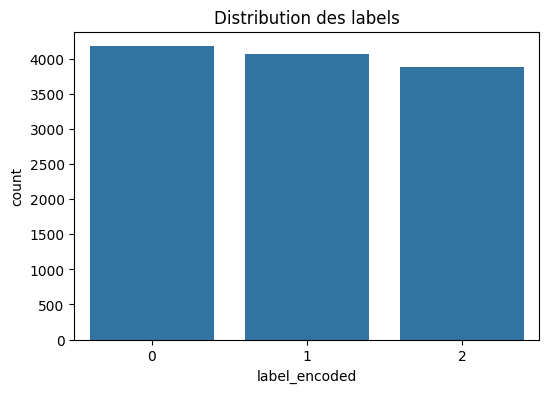

In [24]:
# Vérifier les labels uniques
print("Labels uniques :", df["label"].unique())

# Conversion des labels en valeurs numériques si ce n'est pas déjà fait
label_mapping = {label: idx for idx, label in enumerate(df["label"].unique())}
df["label_encoded"] = df["label"].map(label_mapping)

# Vérifier la répartition des classes
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=df["label_encoded"])
plt.title("Distribution des labels")
plt.show()


In [34]:
from sklearn.model_selection import StratifiedKFold
from collections import Counter

# Initialisation de StratifiedKFold avec 5 splits
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Création d'une liste pour stocker les informations des folds
fold_data = []

# Parcourir les folds et calculer la répartition des classes
for i, (train_idx, val_idx) in enumerate(folds):
    train_labels = df.loc[train_idx, "label_encoded"]
    val_labels = df.loc[val_idx, "label_encoded"]

    # Comptage des classes
    train_counts = dict(Counter(train_labels))
    val_counts = dict(Counter(val_labels))

    # Stocker les résultats sous forme de dictionnaire
    fold_data.append({
        "Fold": i + 1,
        "Train Size": len(train_idx),
        "Val Size": len(val_idx),
        "Train Class 0": train_counts.get(0, 0),
        "Train Class 1": train_counts.get(1, 0),
        "Train Class 2": train_counts.get(2, 0),
        "Val Class 0": val_counts.get(0, 0),
        "Val Class 1": val_counts.get(1, 0),
        "Val Class 2": val_counts.get(2, 0),
    })

# Transformer en DataFrame
folds_df = pd.DataFrame(fold_data)
folds_df.head()

,Fold,Train Size,Val Size,Train Class 0,Train Class 1,Train Class 2,Val Class 0,Val Class 1,Val Class 2
0,1,9696,2424,3340,3252,3104,836,812,776
1,2,9696,2424,3341,3251,3104,835,813,776
2,3,9696,2424,3341,3251,3104,835,813,776
3,4,9696,2424,3341,3251,3104,835,813,776
4,5,9696,2424,3341,3251,3104,835,813,776
